# Safe Infrastructure or Risk Signal? Predicting Serious Collision Severity around Pedestrian Crossing Facilities in London

## Preparation

- [Github link](google.com) *[Optional]*

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

## Research questions

[[ go back to the top ]](#Table-of-contents)

Are pedestrian crossing facilities associated with lower serious-collision severity in London, or do they act as signals of high-risk junction contexts in machine learning predictions?

RQ1: How do severe collision rates vary across pedestrian crossing facility types and junction contexts in London in 2024?

RQ2: Can machine learning models identify serious or fatal collisions in London, and which road-context variables contribute most to severity prediction?

## Data

[[ go back to the top ]](#Table-of-contents)

*[Note: a table that describes the selected variables for analysis and modelling is required - see the example below.]*

| Variable | Source | Type | Description | Notes |
|---|---|---|---|---|
| severe | Collision | Binary | Target variable: 1 = Fatal or Serious collision, 0 = Slight | Derived from collision_severity |
| pedestrian_crossing_physical_facilities_historic | Collision | Categorical | Type of pedestrian crossing facility within 50m of collision | Core variable of interest |
| junction_detail | Collision | Categorical | Type of junction at collision location | 0=Not at junction, 13=T-junction, 16=Crossroads, etc. |
| junction_control | Collision | Categorical | Type of traffic control at junction | 0=None, 2=Auto signal, 4=Give way |
| road_type | Collision | Categorical | Classification of road where collision occurred | Single/dual carriageway, roundabout, etc. |
| speed_limit | Collision | Numeric | Speed limit at collision location in mph | 20, 30, 40, 50, 60, 70 |
| urban_or_rural_area | Collision | Categorical | Urban or rural classification of collision location | 1=Urban, 2=Rural |
| light_conditions | Collision | Categorical | Lighting conditions at time of collision | Daylight, darkness with/without lighting |
| weather_conditions | Collision | Categorical | Weather conditions at time of collision | Fine, rain, snow, fog, etc. |
| road_surface_conditions | Collision | Categorical | Road surface condition at time of collision | Dry, wet, frost, flood |
| day_of_week | Collision | Categorical | Day of week on which collision occurred | 1=Sunday to 7=Saturday |
| hour | Collision | Numeric | Hour of day extracted from collision time | Derived from time field, 0–23 |
| peak_hour | Collision | Binary | Whether collision occurred during peak hours | 1 = 07–09 or 16–19, 0 = otherwise |
| weekend | Collision | Binary | Whether collision occurred on a weekend | Derived from day_of_week |
| has_ped_casualty | Casualty | Binary | Whether collision involved at least one pedestrian casualty | Derived from casualty table join |
| borough_severe_rate | Collision | Numeric | Proportion of severe collisions in the borough | Spatial context proxy, computed from london dataset |
| has_crossing | Collision | Binary | Whether any crossing facility was present within 50m | Derived from pedestrian_crossing_physical_facilities_historic |

In [56]:
# Load all required packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

In [57]:
# Load collision and casualty datasets remotely from GitHub repository

COLLISION_URL = (
    'https://raw.githubusercontent.com/Alexia418/'
    'DSSS_Assessment/main/'
    'dft-road-casualty-statistics-collision-2024.csv'
)
CASUALTY_URL = (
    'https://raw.githubusercontent.com/Alexia418/'
    'DSSS_Assessment/main/'
    'dft-road-casualty-statistics-casualty-2024.csv'
)

collision = pd.read_csv(COLLISION_URL, low_memory=False)
casualty  = pd.read_csv(CASUALTY_URL,  low_memory=False)

print(f"Collision records (GB): {len(collision):,}")
print(f"Casualty records  (GB): {len(casualty):,}")

Collision records (GB): 100,927
Casualty records  (GB): 128,272


In [58]:
# Filter to London collisions only using ONS district codes
# E09 prefix identifies London boroughs in the ONS geography hierarchy

london_col = collision[
    collision['local_authority_ons_district']
    .astype(str).str.startswith('E09')
].copy()

london_cas = casualty[
    casualty['collision_index'].isin(london_col['collision_index'])
].copy()

print(f"London collisions: {len(london_col):,}")
print(f"London casualties: {len(london_cas):,}")
print(f"Unique London boroughs: {london_col['local_authority_ons_district'].nunique()}")

London collisions: 20,967
London casualties: 23,997
Unique London boroughs: 33


In [59]:
# Filter pedestrian casualties and aggregate to collision level for join
# casualty_class = 3 corresponds to Pedestrian in STATS19 coding
# Cross-validated: casualty_type = 0 yields identical results in 2024 data

ped = london_cas[london_cas['casualty_class'] == 3].copy()

print(f"Pedestrian casualties in London: {len(ped):,}")
print(f"Collisions involving pedestrians: {ped['collision_index'].nunique():,}")

ped_agg = ped.groupby('collision_index').agg(
    ped_casualty_count=('casualty_severity', 'count'),
    ped_severe_count=(
        'casualty_severity',
        lambda x: (x.isin([1, 2])).sum()
    ),
    has_ped_casualty=('casualty_severity', lambda x: 1)
).reset_index()

london = london_col.merge(ped_agg, on='collision_index', how='left')
london['has_ped_casualty'] = (
    london['has_ped_casualty'].fillna(0).astype(int)
)

print(f"Merged dataset rows: {len(london):,}")

Pedestrian casualties in London: 4,445
Collisions involving pedestrians: 4,299
Merged dataset rows: 20,967


In [60]:
# Create binary target variable from collision_severity
# 1 = Fatal or Serious; 0 = Slight
# collision_severity: 1 = Fatal, 2 = Serious, 3 = Slight (STATS19 coding)

london['severe'] = london['collision_severity'].apply(
    lambda x: 1 if x in [1, 2] else 0
)

print("Severity distribution (London 2024):")
print(london['severe'].value_counts())
print(f"Severe rate: {london['severe'].mean():.3f}")

Severity distribution (London 2024):
severe
0    17366
1     3601
Name: count, dtype: int64
Severe rate: 0.172


In [61]:
# Engineer temporal and spatial context features from existing fields

# Extract hour from time string (HH:MM format)
london['hour'] = london['time'].str[:2].astype(float)

# Peak hour flag: morning 07-09 and evening 16-19
london['peak_hour'] = london['hour'].apply(
    lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 19) else 0
)

# Weekend flag: day_of_week 1 = Sunday, 7 = Saturday (STATS19 coding)
london['weekend'] = london['day_of_week'].apply(
    lambda x: 1 if x in [1, 7] else 0
)

# Binary crossing indicator: 0 and 9 = no facility; all others = facility present
london['has_crossing'] = (
    london['pedestrian_crossing_physical_facilities_historic']
    .apply(lambda x: 0 if x in [0, 9] else 1)
)

print("Engineered features created: hour, peak_hour, weekend, has_crossing")
print(f"Peak hour collisions: {london['peak_hour'].sum():,}")
print(f"Weekend collisions:   {london['weekend'].sum():,}")
print(f"Has crossing:         {london['has_crossing'].sum():,}")

Engineered features created: hour, peak_hour, weekend, has_crossing
Peak hour collisions: 9,388
Weekend collisions:   5,178
Has crossing:         8,211


In [62]:
# Compute borough-level severe collision rate as a spatial context variable
# Serves as a lightweight neighbourhood risk proxy following Chen et al. (2026)

borough_rate = (
    london.groupby('local_authority_ons_district')['severe']
    .mean()
    .rename('borough_severe_rate')
)

london = london.drop(
    columns=['borough_severe_rate'], errors='ignore'
).join(borough_rate, on='local_authority_ons_district')

print(f"Boroughs with severe rate computed: {borough_rate.shape[0]}")
print("Top 5 boroughs by severe rate:")
print(borough_rate.sort_values(ascending=False).head())

Boroughs with severe rate computed: 33
Top 5 boroughs by severe rate:
local_authority_ons_district
E09000001    0.325301
E09000027    0.268437
E09000028    0.245714
E09000020    0.221631
E09000021    0.214533
Name: borough_severe_rate, dtype: float64


In [63]:
# Inspect ambiguous and missing codes across all key variables before exclusion
# -1 = Data missing or out of range; 99 = Unknown (self reported) in STATS19

pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 120)

AMBIGUOUS_CODES = {
    'pedestrian_crossing_physical_facilities_historic': [-1, 99],
    'junction_detail':          [-1, 99],
    'junction_control':         [-1, 9],
    'road_type':                [-1, 9],
    'speed_limit':              [-1, 99],
    'light_conditions':         [-1],
    'weather_conditions':       [-1, 9],
    'road_surface_conditions':  [-1, 9],
    'urban_or_rural_area':      [-1],
    'day_of_week':              [-1],
}

inspection_rows = []
for col, codes in AMBIGUOUS_CODES.items():
    if col not in london.columns:
        continue
    total       = len(london)
    actual_nan  = london[col].isnull().sum()
    ambig_count = london[col].isin(codes).sum()
    total_miss  = actual_nan + ambig_count
    pct         = total_miss / total * 100
    inspection_rows.append({
        'variable':        col,
        'total_rows':      total,
        'actual_NaN':      actual_nan,
        'ambiguous_count': ambig_count,
        'total_missing':   total_miss,
        'pct_missing':     round(pct, 1)
    })

inspection_df = (
    pd.DataFrame(inspection_rows)
    .sort_values('pct_missing', ascending=False)
)
print("Missing and ambiguous code inspection:")
print(inspection_df.to_string(index=False))

Missing and ambiguous code inspection:
                                        variable  total_rows  actual_NaN  ambiguous_count  total_missing  pct_missing
                                junction_control       20967           0             5880           5880         28.0
                                 junction_detail       20967           0             2256           2256         10.8
                                       road_type       20967           0             2216           2216         10.6
                              weather_conditions       20967           0             1905           1905          9.1
                         road_surface_conditions       20967           0             1625           1625          7.8
pedestrian_crossing_physical_facilities_historic       20967           0              181            181          0.9
                                     speed_limit       20967           0                0              0          0.0
                 

In [64]:
# Define model features grouped by category and set target variable

FEATURES = [
    # Core variable of interest (from collision table)
    'pedestrian_crossing_physical_facilities_historic',
    # Junction context
    'junction_detail',
    'junction_control',
    # Road context
    'road_type',
    'speed_limit',
    'urban_or_rural_area',
    # Environmental conditions
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    # Temporal
    'day_of_week',
    'hour',
    'peak_hour',
    'weekend',
    # Derived from casualty join
    'has_ped_casualty',
    # Spatial context
    'borough_severe_rate',
    # Engineered binary
    'has_crossing',
]

TARGET = 'severe'

In [65]:
# Remove rows with ambiguous or missing codes as defined in STATS19 documentation
# Rows coded -1 (missing) or 99 (unknown) are excluded from modelling

CODED_COLS = [
    'pedestrian_crossing_physical_facilities_historic',
    'junction_detail',
    'junction_control',
    'road_type',
    'speed_limit',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'urban_or_rural_area',
    'day_of_week',
]

INVALID_CODES = [-1, 99]

df_model = london[FEATURES + [TARGET]].copy()

for col in CODED_COLS:
    before = len(df_model)
    df_model = df_model[~df_model[col].isin(INVALID_CODES)]
    removed = before - len(df_model)
    if removed > 0:
        print(f"Removed {removed:>5} rows — invalid codes in: {col}")

df_model = df_model.dropna()

print(f"\nFinal dataset:  {len(df_model):,} rows")
print(f"Severe cases:   {df_model[TARGET].sum():,}")
print(f"Slight cases:   {(df_model[TARGET]==0).sum():,}")
print(f"Severe rate:    {df_model[TARGET].mean():.3f}")

Removed   181 rows — invalid codes in: pedestrian_crossing_physical_facilities_historic
Removed  2245 rows — invalid codes in: junction_detail
Removed  4005 rows — invalid codes in: junction_control

Final dataset:  14,536 rows
Severe cases:   2,516
Slight cases:   12,020
Severe rate:    0.173


In [66]:
# Verify data quality by checking for remaining missing values and data types

print("Missing values per feature:")
missing = df_model[FEATURES].isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "None — all clean")

print(f"\nDataset shape: {df_model.shape}")
print(f"All missing values resolved: {df_model[FEATURES].isnull().sum().sum() == 0}")

Missing values per feature:
None — all clean

Dataset shape: (14536, 17)
All missing values resolved: True


EDA

EDA 1：Severity class distribution

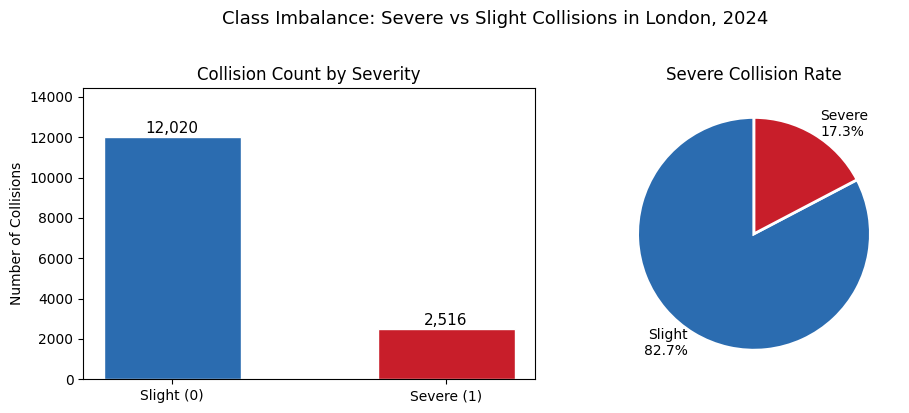

Severe rate: 0.173
Class imbalance ratio (slight:severe) = 4.8:1


In [67]:
# Visualise the distribution of severe and slight collisions to assess class imbalance

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: count bar for context
severity_counts = df_model['severe'].value_counts().sort_index()
severity_labels = ['Slight (0)', 'Severe (1)']

axes[0].bar(severity_labels, severity_counts.values,
            color=colors, edgecolor='white', width=0.5)
for bar, count in zip(axes[0].patches, severity_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{count:,}',
        ha='center', va='bottom', fontsize=11
    )
axes[0].set_title('Collision Count by Severity', fontsize=12)
axes[0].set_ylabel('Number of Collisions')
axes[0].set_ylim(0, severity_counts.max() * 1.2)

# Right: rate pie chart
rates = [1 - df_model['severe'].mean(), df_model['severe'].mean()]
axes[1].pie(
    rates,
    labels=[f'Slight\n{rates[0]*100:.1f}%',
            f'Severe\n{rates[1]*100:.1f}%'],
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Severe Collision Rate', fontsize=12)

plt.suptitle(
    'Class Imbalance: Severe vs Slight Collisions in London, 2024',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

print(f"Severe rate: {df_model['severe'].mean():.3f}")
print(f"Class imbalance ratio (slight:severe) = "
      f"{(df_model['severe']==0).sum() / df_model['severe'].sum():.1f}:1")

17.3% vs 82.7%

EDA 2：Severe rate by crossing facility type

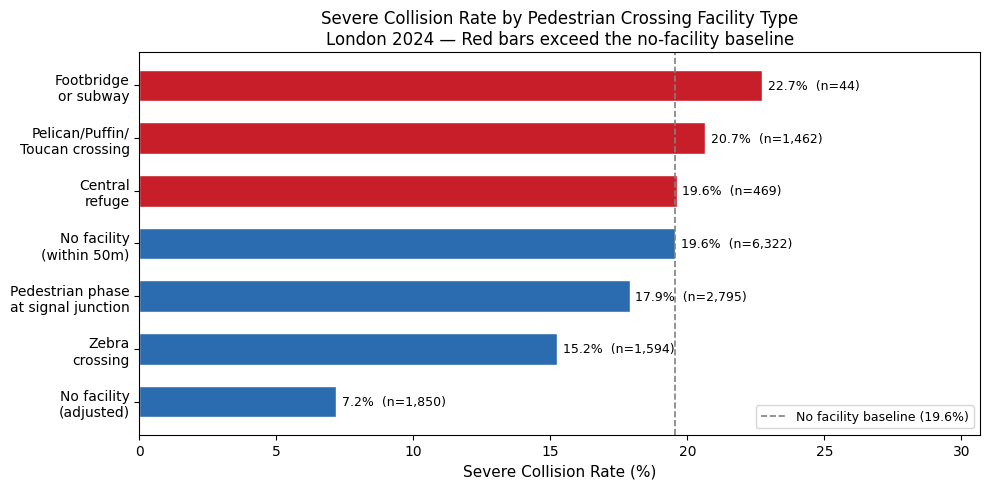

In [68]:
# Compare severe collision rates across pedestrian crossing facility types
# Rates are used rather than counts to enable fair comparison across facility types

# Mapping codes to labels using STATS19 data guide
facility_labels = {
    0: 'No facility\n(within 50m)',
    1: 'Zebra\ncrossing',
    4: 'Pelican/Puffin/\nToucan crossing',
    5: 'Pedestrian phase\nat signal junction',
    7: 'Footbridge\nor subway',
    8: 'Central\nrefuge',
    9: 'No facility\n(adjusted)'
}

crossing_rate = (
    df_model.groupby('pedestrian_crossing_physical_facilities_historic')['severe']
    .agg(severe_rate='mean', count='count')
    .reset_index()
)
crossing_rate['label'] = (
    crossing_rate['pedestrian_crossing_physical_facilities_historic']
    .map(facility_labels)
    .fillna('Other')
)
crossing_rate = crossing_rate.sort_values('severe_rate', ascending=True)

# Highlight bars above the no-facility baseline
no_facility_rate = crossing_rate[
    crossing_rate['pedestrian_crossing_physical_facilities_historic'] == 0
]['severe_rate'].values[0]


fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    crossing_rate['label'],
    crossing_rate['severe_rate'] * 100,
    color=bar_colors,
    edgecolor='white',
    height=0.6
)

# Add rate labels
for bar, rate, n in zip(
    bars,
    crossing_rate['severe_rate'],
    crossing_rate['count']
):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{rate*100:.1f}%  (n={n:,})',
        va='center', fontsize=9
    )

# Reference line: no facility rate
ax.axvline(
    no_facility_rate * 100,
    color='grey', linestyle='--', linewidth=1.2,
    label=f'No facility baseline ({no_facility_rate*100:.1f}%)'
)

ax.set_xlabel('Severe Collision Rate (%)', fontsize=11)
ax.set_title(
    'Severe Collision Rate by Pedestrian Crossing Facility Type\n'
    'London 2024 — Red bars exceed the no-facility baseline',
    fontsize=12
)
ax.legend(fontsize=9)
ax.set_xlim(0, crossing_rate['severe_rate'].max() * 100 * 1.35)
plt.tight_layout()
plt.show()

Footbridge/Subway 22.7% > No facility baseline 19.6%
Pelican/Puffin 20.7% > baseline
Zebra crossing反而只有15.2%，低于baseline

EDA 3：Crossing × Junction heatmap（rate）

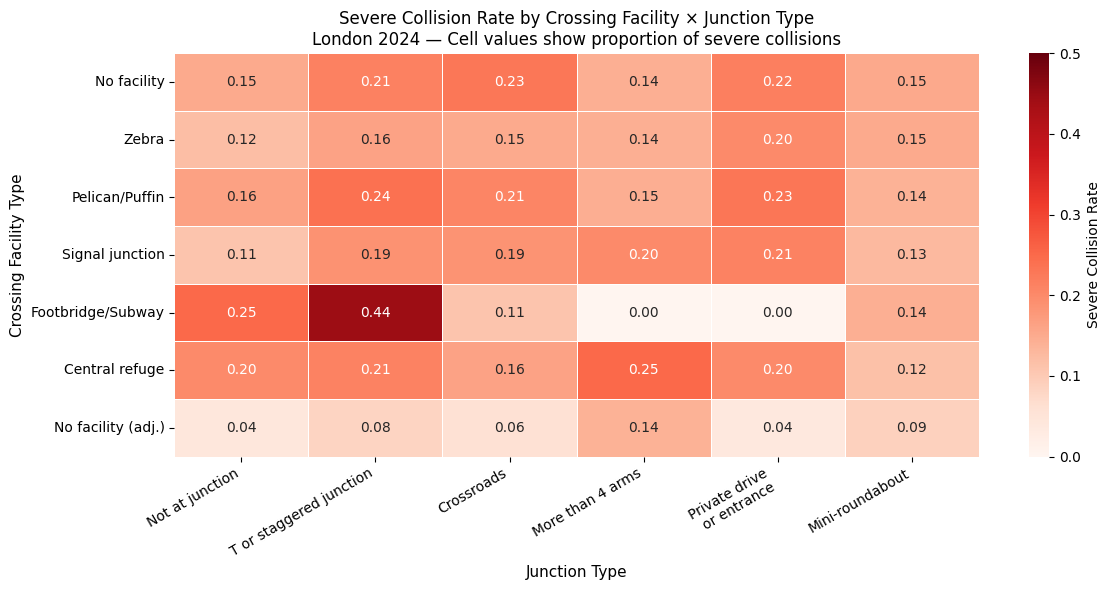

Key observation: severe rate ranges from 0.00 to 0.44 across crossing-junction combinations


In [69]:
# Examine how severe collision rates vary across combinations of
# crossing facility type and junction detail to reveal context-dependence

junction_labels = {
    0:  'Not at junction',
    13: 'T or staggered junction',
    16: 'Crossroads',
    17: 'More than 4 arms',
    18: 'Private drive\nor entrance',
    19: 'Mini-roundabout'
}

crossing_labels_short = {
    0: 'No facility',
    1: 'Zebra',
    4: 'Pelican/Puffin',
    5: 'Signal junction',
    7: 'Footbridge/Subway',
    8: 'Central refuge',
    9: 'No facility (adj.)'
}

# Filter to junction codes with sufficient sample size
valid_junctions = [0, 13, 16, 17, 18, 19]
plot_df = df_model[
    df_model['junction_detail'].isin(valid_junctions)
].copy()

pivot = (
    plot_df.groupby([
        'pedestrian_crossing_physical_facilities_historic',
        'junction_detail'
    ])['severe']
    .mean()
    .unstack()
)

pivot.index = [
    crossing_labels_short.get(i, str(i))
    for i in pivot.index
]
pivot.columns = [
    junction_labels.get(c, str(c))
    for c in pivot.columns
]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.2f',
    cmap='Reds',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    vmin=0,
    vmax=0.5,
    cbar_kws={'label': 'Severe Collision Rate'}
)

ax.set_title(
    'Severe Collision Rate by Crossing Facility × Junction Type\n'
    'London 2024 — Cell values show proportion of severe collisions',
    fontsize=12
)
ax.set_xlabel('Junction Type', fontsize=11)
ax.set_ylabel('Crossing Facility Type', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Key observation: severe rate ranges from "
      f"{pivot.min().min():.2f} to {pivot.max().max():.2f} "
      "across crossing-junction combinations")

Footbridge × T-junction = 0.44，是整张图最高的格子。这直接支持你的核心论点：crossing facility的风险取决于junction context，不能孤立解释

EDA 4：Borough-level choropleth (severe rate)

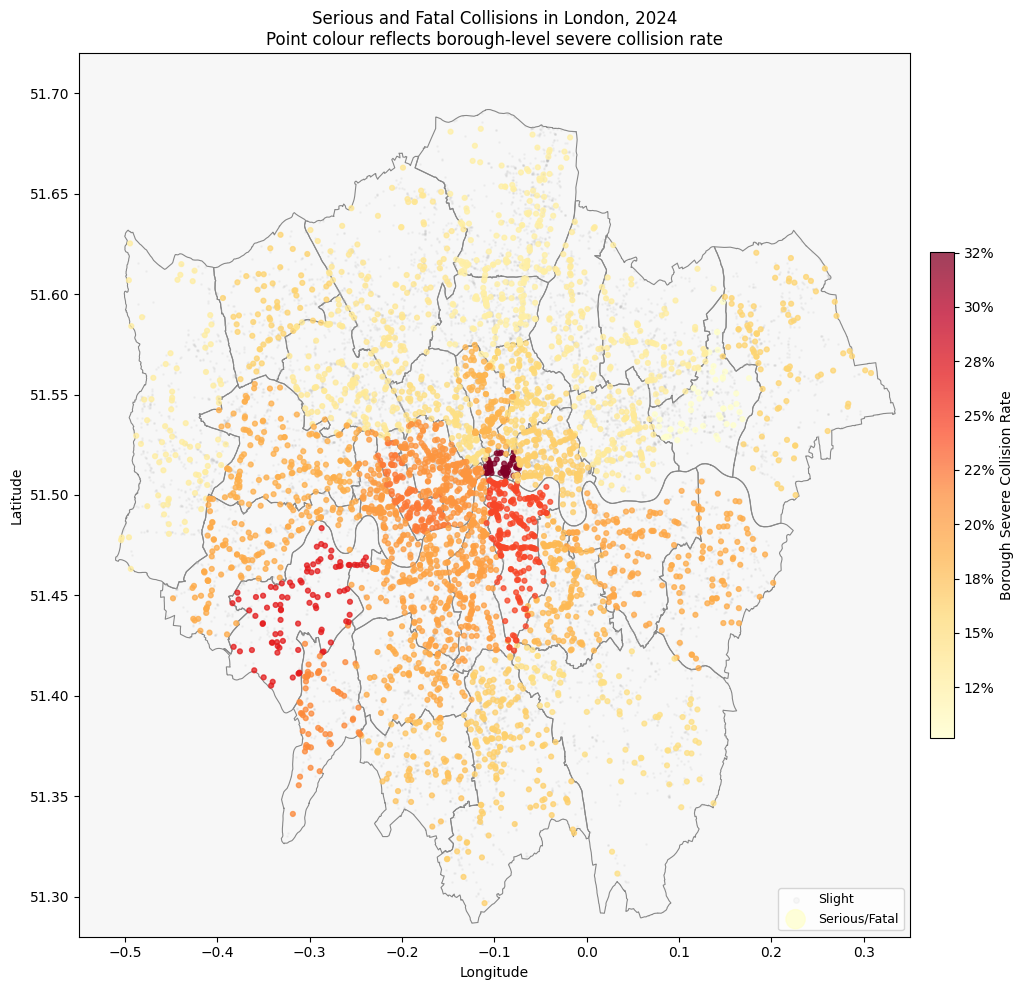

Severe collisions plotted: 3,601
Slight collisions plotted: 17,366


In [75]:
# Map serious and fatal collisions in London with borough boundary outlines
# Borough boundaries fetched as GeoJSON via requests and drawn with matplotlib
# Point colour reflects borough-level severe rate; rate used not count

import requests

fig, ax = plt.subplots(figsize=(11, 10))

# Fetch London borough boundary GeoJSON
geojson_url = (
    'https://raw.githubusercontent.com/radoi90/housequest-data/'
    'master/london_boroughs.geojson'
)
response = requests.get(geojson_url, timeout=10)
borough_geojson = response.json()

# Draw borough outlines only — no fill, just boundary lines
for feature in borough_geojson['features']:
    geom_type = feature['geometry']['type']
    coords_list = feature['geometry']['coordinates']

    if geom_type == 'Polygon':
        coords_list = [coords_list]

    for polygon_coords in coords_list:
        outer_ring = polygon_coords[0]
        xs = [pt[0] for pt in outer_ring]
        ys = [pt[1] for pt in outer_ring]
        ax.fill(xs, ys, color='#f7f7f7', zorder=0)
        ax.plot(xs, ys, color='#888888',
                linewidth=0.8, zorder=1)

# Plot slight collisions as light background dots
slight = london[london['severe'] == 0]
ax.scatter(
    slight['longitude'], slight['latitude'],
    s=1, alpha=0.1, c='#bbbbbb',
    label='Slight', zorder=2
)

# Plot severe collisions coloured by borough severe rate
severe = london[london['severe'] == 1].copy()
sc = ax.scatter(
    severe['longitude'], severe['latitude'],
    s=12, alpha=0.75,
    c=severe['borough_severe_rate'],
    cmap='YlOrRd',
    label='Serious/Fatal',
    zorder=3
)

# Colourbar showing borough severe rate
cbar = plt.colorbar(sc, ax=ax, shrink=0.55, pad=0.02)
cbar.set_label('Borough Severe Collision Rate', fontsize=10)
cbar.ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}')
)

ax.set_xlim(-0.55, 0.35)
ax.set_ylim(51.28, 51.72)
ax.set_facecolor('#f7f7f7')

ax.set_title(
    'Serious and Fatal Collisions in London, 2024\n'
    'Point colour reflects borough-level severe collision rate',
    fontsize=12
)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.legend(markerscale=4, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

print(f"Severe collisions plotted: {len(severe):,}")
print(f"Slight collisions plotted: {len(slight):,}")

颜色深浅反映borough severe rate，City of London（中间最深的紫红色小点）severe rate最高0.325，符合E09000001是City of London的事实。

## Methodology

[[ go back to the top ]](#Table-of-contents)

*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

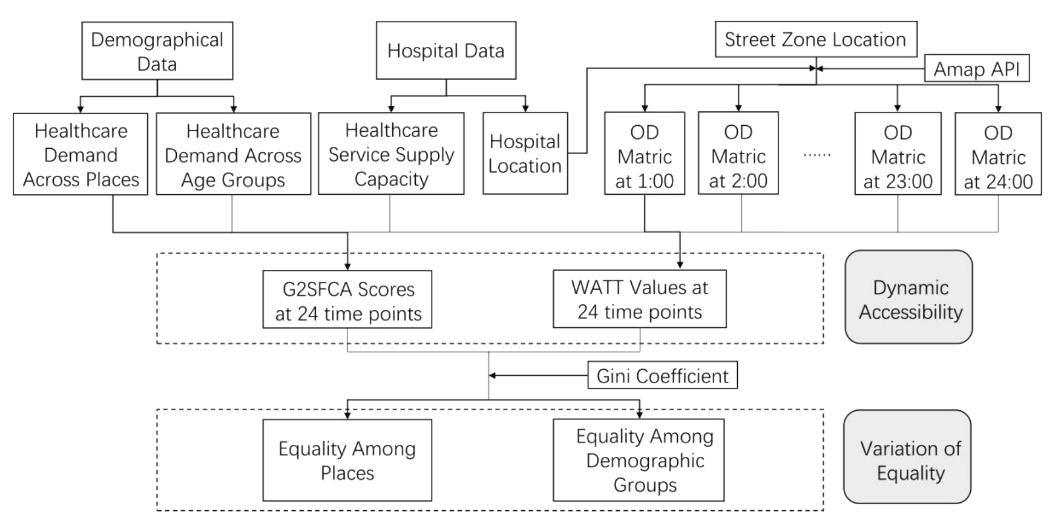

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

In [71]:
# Train/Test Split and Encoding
# Categorical features treated as strings before get_dummies
# Follows course practical: supervised_learning_workflow

from sklearn.model_selection import train_test_split

# Identify categorical vs continuous features
CAT_FEATURES = [
    'pedestrian_crossing_physical_facilities_historic',
    'junction_detail',
    'junction_control',
    'road_type',
    'urban_or_rural_area',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'day_of_week',
    'peak_hour',
    'weekend',
    'has_ped_casualty',
    'has_crossing',
]

NUM_FEATURES = [
    'speed_limit',
    'hour',
    'borough_severe_rate',
]

# One-hot encode categorical features
df_encoded = df_model.copy()
df_encoded[CAT_FEATURES] = df_encoded[CAT_FEATURES].astype(str)
df_encoded = pd.get_dummies(df_encoded, columns=CAT_FEATURES)

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:   {X_train.shape}")
print(f"Test set:       {X_test.shape}")
print(f"Train severe rate: {y_train.mean():.3f}")
print(f"Test severe rate:  {y_test.mean():.3f}")

Training set:   (11628, 63)
Test set:       (2908, 63)
Train severe rate: 0.173
Test severe rate:  0.173


## Conclusion

[[ go back to the top ]](#Table-of-contents)

## References

[[ go back to the top ]](#Table-of-contents)